# Basic GAN - Handwritten Digit Generation (MNIST)
Train a Generator and Discriminator to generate realistic MNIST digit images.

In [1]:
!pip install tensorflow matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(X_train, _), _ = keras.datasets.mnist.load_data()
X_train = (X_train.astype('float32') - 127.5) / 127.5  # Normalize to [-1, 1]
X_train = X_train.reshape(-1, 784)
print('MNIST loaded. Shape:', X_train.shape)

MNIST loaded. Shape: (60000, 784)


In [3]:
LATENT_DIM = 100

# Generator
def build_generator():
    return keras.Sequential([
        layers.Dense(256, input_shape=(LATENT_DIM,)),
        layers.LeakyReLU(0.2),
        layers.BatchNormalization(),
        layers.Dense(512),
        layers.LeakyReLU(0.2),
        layers.BatchNormalization(),
        layers.Dense(1024),
        layers.LeakyReLU(0.2),
        layers.BatchNormalization(),
        layers.Dense(784, activation='tanh')
    ], name='Generator')

# Discriminator
def build_discriminator():
    return keras.Sequential([
        layers.Dense(1024, input_shape=(784,)),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Dense(512),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Dense(256),
        layers.LeakyReLU(0.2),
        layers.Dense(1, activation='sigmoid')
    ], name='Discriminator')

generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(optimizer=keras.optimizers.Adam(0.0002, 0.5), loss='binary_crossentropy', metrics=['accuracy'])
print('Generator and Discriminator built.')

C:\Users\chhav\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Generator and Discriminator built.


In [4]:
# GAN = Generator + frozen Discriminator
discriminator.trainable = False
gan_input = keras.Input(shape=(LATENT_DIM,))
gan_output = discriminator(generator(gan_input))
gan = keras.Model(gan_input, gan_output, name='GAN')
gan.compile(optimizer=keras.optimizers.Adam(0.0002, 0.5), loss='binary_crossentropy')
gan.summary()

Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Generator (Sequential)          │ (None, 784)            │     1,493,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │     1,460,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,953,745 (11.27 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 1,463,809 (5.58 MB)

In [5]:
def plot_generated_images(epoch, generator, n=25):
    noise = np.random.normal(0, 1, (n, LATENT_DIM))
    gen_imgs = generator.predict(noise, verbose=0).reshape(n, 28, 28)
    gen_imgs = 0.5 * gen_imgs + 0.5  # rescale to [0,1]
    fig, axes = plt.subplots(5, 5, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(gen_imgs[i], cmap='gray')
        ax.axis('off')
    plt.suptitle(f'Generated Digits at Epoch {epoch}')
    plt.tight_layout()
    plt.show()

print('Helper function ready.')

Helper function ready.


C:\Users\chhav\AppData\Roaming\Python\Python312\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 25/100 | D Loss: 0.7098 | G Loss: 0.5566
Epoch 50/100 | D Loss: 0.7579 | G Loss: 0.4356
Epoch 75/100 | D Loss: 0.8202 | G Loss: 0.3539
Epoch 100/100 | D Loss: 0.8980 | G Loss: 0.2974


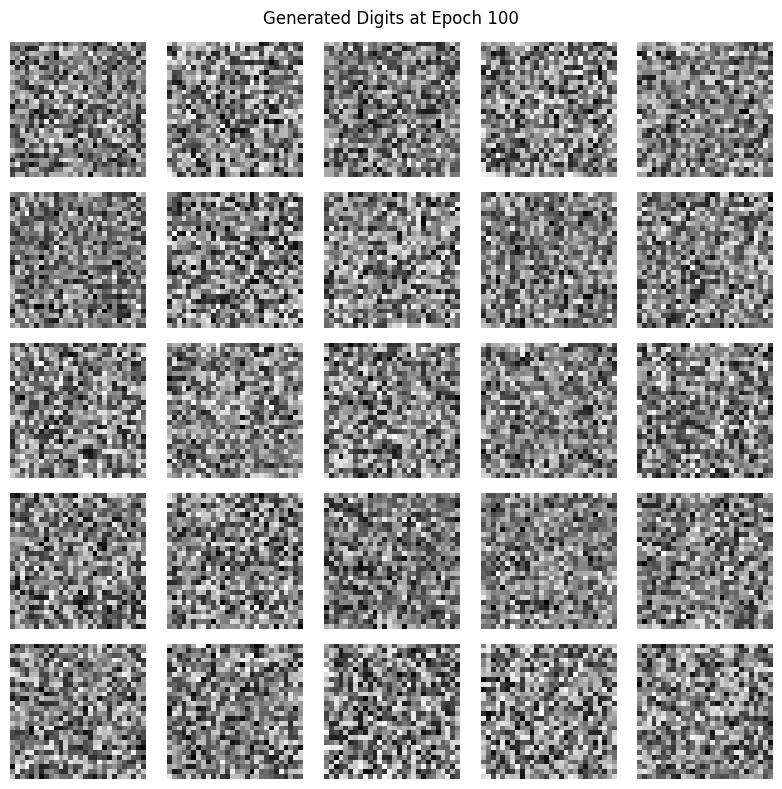

In [6]:
BATCH_SIZE = 128
EPOCHS = 100  # Increase to 5000+ for better results
d_losses, g_losses = [], []

real_labels = np.ones((BATCH_SIZE, 1))
fake_labels = np.zeros((BATCH_SIZE, 1))

for epoch in range(1, EPOCHS+1):
    # Train Discriminator
    idx = np.random.randint(0, X_train.shape[0], BATCH_SIZE)
    real_imgs = X_train[idx]
    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_imgs, fake_labels)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train Generator
    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    g_loss = gan.train_on_batch(noise, real_labels)

    d_losses.append(d_loss[0])
    g_losses.append(g_loss)

    if epoch % 25 == 0:
        print(f'Epoch {epoch}/{EPOCHS} | D Loss: {d_loss[0]:.4f} | G Loss: {g_loss:.4f}')

plot_generated_images(EPOCHS, generator)

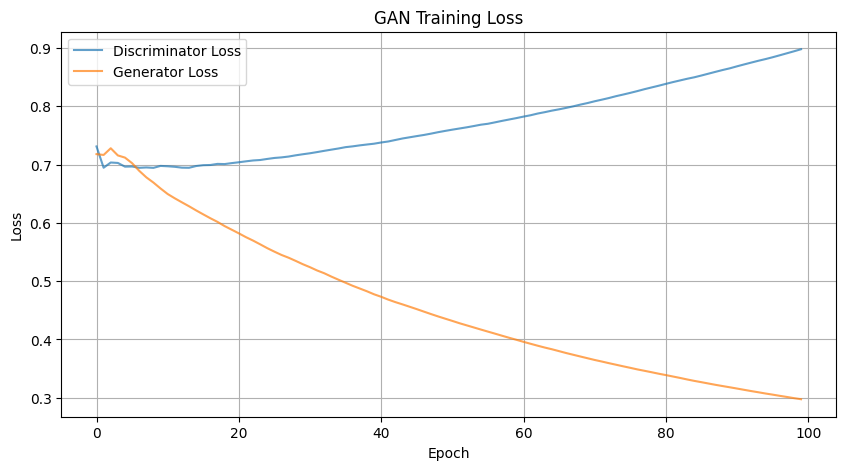

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label='Discriminator Loss', alpha=0.7)
plt.plot(g_losses, label='Generator Loss', alpha=0.7)
plt.title('GAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
plt.savefig("plot.png")

<Figure size 640x480 with 0 Axes>